In [1]:
import sys
sys.path.append('../')
from utils_models import *
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt

In [2]:
max_ql = 21
max_ol = 98


system = FluxoniumOscillatorSystem(
    EJ = 2.75,
    EC = 0.6,
    EL = 0.13,
    Er = 7.20701708,
    g_strength = 0.23,
    qubit_level = max_ql,
    osc_level = max_ol,
    products_to_keep=[[ql, ol] for ql in [1,2] for ol in range(50) ],
    computaional_states = '1,2',
    )


In [3]:
from copy import deepcopy

system_computational = system

dressed_op = system.hilbertspace.op_in_dressed_eigenbasis(system.osc.n_operator).full()
operator_bare = system.osc.n_operator()
n_lvls = max_ol-1
for i in range(n_lvls):
    for ql in [1,2]:
        dressed_lvl_i = system.product_to_dressed[(ql, i)]
        dressed_lvl_ip1 = system.product_to_dressed[(ql, i+1)]
        first_sign = np.imag(operator_bare[i, i+1]) > 0 
        if np.imag(dressed_op[dressed_lvl_i, dressed_lvl_ip1]) < 0:
            dressed_op[dressed_lvl_i, dressed_lvl_ip1] *= -1
            dressed_op[dressed_lvl_ip1, dressed_lvl_i] *= -1

dressed_op = qutip.Qobj(dressed_op)

In [4]:
n_lvls = 20

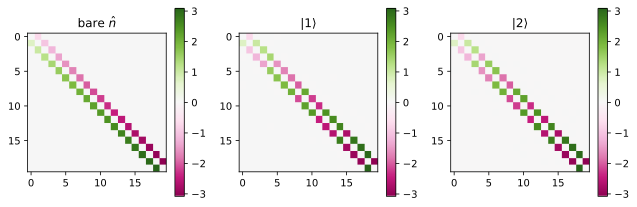

In [5]:
operator_dressed = system.hilbertspace.op_in_dressed_eigenbasis(system.osc.n_operator)
# operator_dressed = dressed_op

operator_bare = system.osc.n_operator()

fig, axes = plt.subplots(1, 3, figsize=(9, 3))  # 1 row, 3 columns

array1 = np.zeros((n_lvls, n_lvls))
for i in range(n_lvls):
    for j in range(n_lvls):
        array1[i, j] = np.imag(operator_bare[i, j])

array2 = np.zeros((n_lvls, n_lvls))
for i in range(n_lvls):
    for j in range(n_lvls):
        array2[i, j] = np.imag(operator_dressed[system.product_to_dressed[(1, i)], system.product_to_dressed[(1, j)]])

array3 = np.zeros((n_lvls, n_lvls))
for i in range(n_lvls):
    for j in range(n_lvls):
        array3[i, j] = np.imag(operator_dressed[system.product_to_dressed[(2, i)], system.product_to_dressed[(2, j)]])

arrays = [array1,array2,array3]
titles = [r'bare $\hat{{n}}$',r'$|1\rangle$', r'$|2\rangle$']
for i, ax in enumerate(axes):
    im = ax.imshow(arrays[i], cmap='PiYG', interpolation='nearest')
    ax.set_title(titles[i])
    fig.colorbar(im, ax=ax)  


plt.tight_layout()  # Adjust the layout to make room for the colorbar
plt.show()


In [6]:
bare_element_signs = [np.imag(operator_bare[i, i+1]) > 0 for i in range(n_lvls)]
dressed_q1_element_signs = [np.imag(operator_dressed[system.product_to_dressed[(1, i)], system.product_to_dressed[(1, i+1)]]) > 0 for i in range(n_lvls)]
dressed_q2_element_signs = [np.imag(operator_dressed[system.product_to_dressed[(2, i)], system.product_to_dressed[(2, i+1)]]) > 0 for i in range(n_lvls)]

dressed_lvl_wrong_phase = [False]
last_lvl_wrong_phase = False
last_lvl_q1_flipped = False
last_lvl_q2_flipped = False

for i in range(0,n_lvls):

    if dressed_q1_element_signs[i] != last_lvl_q1_flipped:
        last_lvl_q1_flipped = True
    else:
        last_lvl_q1_flipped = False
    if dressed_q2_element_signs[i] != last_lvl_q2_flipped:
        last_lvl_q2_flipped = True
    else:
        last_lvl_q2_flipped = False
    
    if last_lvl_q1_flipped == last_lvl_q2_flipped:
        pass
    else:
        last_lvl_wrong_phase = not last_lvl_wrong_phase

    dressed_lvl_wrong_phase.append(last_lvl_wrong_phase)


for i in range(n_lvls):
    print(f"dressed states {i} flipped: {dressed_lvl_wrong_phase[i]}")

dressed states 0 flipped: False
dressed states 1 flipped: False
dressed states 2 flipped: False
dressed states 3 flipped: False
dressed states 4 flipped: True
dressed states 5 flipped: True
dressed states 6 flipped: False
dressed states 7 flipped: True
dressed states 8 flipped: False
dressed states 9 flipped: True
dressed states 10 flipped: True
dressed states 11 flipped: True
dressed states 12 flipped: True
dressed states 13 flipped: False
dressed states 14 flipped: True
dressed states 15 flipped: False
dressed states 16 flipped: True
dressed states 17 flipped: False
dressed states 18 flipped: True
dressed states 19 flipped: False


# next question, is the sign in the dressed operator an error or it is what it is?

In [5]:
import scqubits.utils.spectrum_utils as spec_utils

truncated_dim = system.hilbertspace.dimension
op = system.osc.n_operator
op_in_bare_eigenbasis = False
subsys_index = 1

bare_evecs = system.hilbertspace._data["bare_evecs"][subsys_index][0]
id_wrapped_op = spec_utils.identity_wrap(
    op,
    system.hilbertspace.subsystem_list[subsys_index],
    system.hilbertspace.subsystem_list,
    op_in_eigenbasis=op_in_bare_eigenbasis,
    evecs=bare_evecs,
)
dressed_evecs = system.hilbertspace._data["evecs"][0]
dressed_op_data =  id_wrapped_op.transform(dressed_evecs).data.toarray()
dressed_op_truncated = qutip.Qobj(
    dressed_op_data[0:truncated_dim, 0:truncated_dim],
    dims=[[truncated_dim], [truncated_dim]],
)

## There's no problem with id_wrapped_op

In [6]:
for i in range(max_ol-1):
    print(id_wrapped_op.full().reshape(max_ql,max_ol,max_ql,max_ol)[1,i,1,i+1])

-0.7071067811865475j
-1j
-1.224744871391589j
-1.414213562373095j
-1.5811388300841895j
-1.732050807568877j
-1.8708286933869707j
-2j
-2.1213203435596424j
-2.23606797749979j
-2.3452078799117144j
-2.449489742783178j
-2.5495097567963922j
-2.6457513110645903j
-2.7386127875258306j
-2.82842712474619j
-2.91547594742265j
-2.9999999999999996j
-3.0822070014844885j


## There's sign change after id_wrapped_op.transform(dressed_evecs)

In [7]:
for i in range(max_ol-1):
    print(dressed_op_truncated.full()[system.product_to_dressed[(1, i)], system.product_to_dressed[(1, i+1)]])

0.7070684533140836j
-0.9999458188202969j
-1.224678540964576j
1.414137002566321j
-1.581053269357858j
1.7319571196324213j
1.8707275411210218j
1.999891908859999j
-2.12120574350464j
2.2359472289291027j
-2.3450812906904503j
2.4493575799454095j
2.549372254891682j
2.6456086782930903j
-2.7384652103628837j
2.828274771503446j
2.9153189710136442j
-2.9998382826454075j
3.080705471140059j


In [8]:
type(id_wrapped_op)

qutip.qobj.Qobj

# The eigenstate represented in LC basis has a negative sign.

In [55]:
evals, evecs = system.hilbertspace.hamiltonian().eigenstates()

for i in range(80):
    arr = np.array(evecs[i])
    max_abs_index = np.argmax(np.abs(arr))
    max_abs_value = arr[max_abs_index]
    if max_abs_value > 0:
        pass
    elif max_abs_value < 0:
        print(f"{i}-negative {arr[max_abs_index]}")


4-negative [-0.99993072+0.j]
6-negative [-0.99986628+0.j]
11-negative [-0.99945335+0.j]
14-negative [-0.99972062+0.j]
15-negative [-0.99980872+0.j]
17-negative [-0.99962108+0.j]
19-negative [-0.9795823+0.j]
20-negative [-0.99955383+0.j]
22-negative [-0.9989055+0.j]
23-negative [-0.99884292+0.j]
24-negative [-0.99974604+0.j]
27-negative [-0.99956851+0.j]
29-negative [-0.97062442+0.j]
31-negative [-0.99927598+0.j]
33-negative [-0.99836998+0.j]
34-negative [-0.9982886+0.j]
35-negative [-0.99962475+0.j]
37-negative [-0.99956474+0.j]
40-negative [-0.96194662+0.j]
41-negative [-0.96137025+0.j]
43-negative [-0.99927238+0.j]
44-negative [-0.9978464+0.j]
45-negative [-0.99774614+0.j]
46-negative [-0.99950368+0.j]
48-negative [-0.99944277+0.j]
49-negative [-0.99922945+0.j]
50-negative [-0.99888577+0.j]
51-negative [-0.95372757+0.j]
54-negative [-0.99907704+0.j]
56-negative [-0.99721517+0.j]
57-negative [-0.99938285+0.j]
59-negative [-0.99932079+0.j]
61-negative [-0.99864077+0.j]
63-negative [-0.